# Model Comparison: Full Tree vs. Myopic vs. No-Tree (Open-Source Models)

Compares three fitting variants:
- **Full**: minimax backpropagation over the LLM's entire reasoning tree
- **Myopic**: depth-1 evaluation using only the LLM's root-level candidates (no backprop)
- **No-tree**: depth-1 evaluation over *all* legal moves (ignores the LLM's tree entirely)

Key question: does the LLM's tree depth add predictive value beyond its root-level candidates?

In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path
from scipy.stats import wilcoxon

plt.rcParams.update({'axes.spines.top': False, 'axes.spines.right': False})
RESULTS_DIR = Path('./results')

## 1. Load results

In [2]:

# ── name mapping (raw model_names → display name) ──────────────────────────
name_replacement = {
    'accounts/fireworks/models/deepseek-r1-0528-medium':          'deepseek-r1',
    'accounts/fireworks/models/deepseek-v3p1-medium':             'deepseek-v3.1-thinking',
    'accounts/fireworks/models/glm-4p5-medium':                   'glm-4.5-thinking',
    'accounts/fireworks/models/kimi-k2-instruct-0905':            'kimi-k2-instruct',
    'accounts/fireworks/models/llama-v3p3-70b-instruct':          'llama-v3.3-70b',
    'accounts/fireworks/models/qwen3-235b-a22b-thinking-2507-medium': 'qwen3-235b-a22b-thinking',
    'claude-opus-4-1-20250805':        'claude-opus-4.1',
    'claude-sonnet-4-20250514':        'claude-sonnet-4',
    'claude-sonnet-4-5@20250929':      'claude-sonnet-4.5',
    'deepseek-ai/deepseek-v3.1-maas':  'deepseek-v3.1',
    'deepseek-reasoner':               'deepseek-v3.2-thinking',
    'gemini-2.5-pro':                  'gemini-2.5-pro',
    'glm-4.6':                         'glm-4.6',
    'gpt-4o-2024-08-06':               'gpt-4o',
    'gpt-5-2025-08-07-high':           'gpt-5-high',
    'gpt-5-2025-08-07-medium':         'gpt-5-medium',
    'gpt-5-mini-2025-08-07-high':      'gpt-5-mini-high',
    'gpt-5-mini-2025-08-07-medium':    'gpt-5-mini-medium',
    'grok-4-fast-reasoning':           'grok-4-fast-reasoning',
    'kimi-k2-thinking':                'kimi-k2-thinking',
    'o3-2025-04-16-high':              'o3-high',
    'openai/gpt-oss-120b-maas-high':   'gpt-oss-120b-high',
    'openai/gpt-oss-120b-maas-medium': 'gpt-oss-120b-medium',
    'qwen/qwen3-next-80b-a3b-thinking-maas': 'qwen3-next-80b-a3b-thinking',
    'qwen3-max':                       'qwen3-max',
}

def is_open_source(model_name):
    keys = ['deepseek', 'glm', 'kimi', 'llama', 'qwen', 'oss']
    return any(k in model_name.lower() for k in keys)

# ── discover model names from result filenames ─────────────────────────────
full_files = sorted(RESULTS_DIR.glob('fit_results_full_*.json'))
full_files = [f for f in full_files if not f.stem.endswith(('_myopic', '_notree', '_gamma'))]

safe_to_raw = {raw.replace('/', '_').replace('@', '_'): raw for raw in name_replacement}
all_safe_names = [f.stem.replace('fit_results_full_', '') for f in full_files]
print(f'Found {len(all_safe_names)} models with full-fit results')

# ── load full / myopic / notree / gamma results ────────────────────────────
records = []
VARIANTS = {'full': '', 'myopic': '_myopic', 'notree': '_notree', 'gamma': '_gamma'}

for safe_name in all_safe_names:
    raw_name     = safe_to_raw.get(safe_name, safe_name.replace('_', '/'))
    display_name = name_replacement.get(raw_name, safe_name)

    if not is_open_source(display_name):
        continue

    for variant, suffix in VARIANTS.items():
        path = RESULTS_DIR / f'fit_results_full_{safe_name}{suffix}.json'
        if not path.exists():
            print(f'  MISSING: {path.name}')
            continue
        with open(path) as f:
            d = json.load(f)
        records.append({
            'model':         display_name,
            'variant':       variant,
            'n_samples':     d['n_samples'],
            'nll':           d['train_nll_per_sample'],
            'nll_chance':    d['train_nll_chance'] / d['n_samples'],
            'accuracy':      d['train_accuracy'],
            'chance_acc':    d['train_chance_accuracy'],
            'fitted_gamma':  d.get('gamma', float('nan')),  # only present in gamma variant
        })

df = pd.DataFrame(records)

# ── filter: keep only models with more than 20 samples (full-tree fit) ────
full_n = df[df['variant'] == 'full'].set_index('model')['n_samples']
excluded = full_n[full_n <= 20].index.tolist()
if excluded:
    print(f'Excluded (n_samples <= 20): {excluded}')
models_ok = full_n[full_n > 20].index
df = df[df['model'].isin(models_ok)].reset_index(drop=True)

print(f'\nLoaded {len(df)} rows  ({df["model"].nunique()} models × {df["variant"].nunique()} variants)')
df.head(8)


Found 25 models with full-fit results
Excluded (n_samples <= 20): ['llama-v3.3-70b']

Loaded 52 rows  (13 models × 4 variants)


,model,variant,n_samples,nll,nll_chance,accuracy,chance_acc,fitted_gamma
0,deepseek-r1,full,605,1.701366,1.866605,0.363636,0.042885,NaN
1,deepseek-r1,myopic,605,1.308627,1.866605,0.568595,0.042885,NaN
2,deepseek-r1,notree,605,1.651436,3.263865,0.480992,0.042885,NaN
3,deepseek-r1,gamma,605,1.308627,1.866605,0.550413,0.042885,5.251962e-09
4,deepseek-v3.1-thinking,full,629,1.583755,1.890246,0.486486,0.043042,NaN
5,deepseek-v3.1-thinking,myopic,629,1.230388,1.890246,0.607313,0.043042,NaN
6,deepseek-v3.1-thinking,notree,629,1.651693,3.263363,0.538951,0.043042,NaN
7,deepseek-v3.1-thinking,gamma,629,1.230388,1.890246,0.581876,0.043042,2.472929e-09


## 2. Wide-format summary table

In [3]:

wide = df.pivot(index='model', columns='variant', values=['nll', 'accuracy'])
wide.columns = [f'{metric}_{var}' for metric, var in wide.columns]

# delta columns: full vs baselines (positive = full is BETTER)
wide['delta_acc_full_vs_myopic']  = wide['accuracy_full']  - wide['accuracy_myopic']
wide['delta_acc_full_vs_notree']  = wide['accuracy_full']  - wide['accuracy_notree']
wide['delta_acc_full_vs_gamma']   = wide['accuracy_full']  - wide['accuracy_gamma']
wide['delta_nll_full_vs_myopic']  = wide['nll_myopic']     - wide['nll_full']
wide['delta_nll_full_vs_notree']  = wide['nll_notree']     - wide['nll_full']
wide['delta_nll_full_vs_gamma']   = wide['nll_gamma']      - wide['nll_full']

wide = wide.sort_values('accuracy_full', ascending=False)
pd.set_option('display.float_format', '{:.4f}'.format)
wide[['accuracy_full', 'accuracy_myopic', 'accuracy_notree', 'accuracy_gamma',
      'delta_acc_full_vs_myopic', 'delta_acc_full_vs_notree', 'delta_acc_full_vs_gamma']]


,accuracy_full,accuracy_myopic,accuracy_notree,accuracy_gamma,delta_acc_full_vs_myopic,delta_acc_full_vs_notree,delta_acc_full_vs_gamma
model,,,,,,,
kimi-k2-instruct,0.5735,0.5877,0.3934,0.5877,-0.0142,0.1801,-0.0142
gpt-oss-120b-medium,0.5563,0.5599,0.4296,0.5581,-0.0035,0.1268,-0.0018
deepseek-v3.1,0.5042,0.5722,0.3796,0.5694,-0.0680,0.1246,-0.0652
qwen3-max,0.4989,0.6287,0.4852,0.6287,-0.1298,0.0137,-0.1298
deepseek-v3.1-thinking,0.4865,0.6073,0.5390,0.5819,-0.1208,-0.0525,-0.0954
qwen3-235b-a22b-thinking,0.4851,0.6175,0.5646,0.5977,-0.1325,-0.0795,-0.1126
gpt-oss-120b-high,0.4825,0.6032,0.5825,0.5857,-0.1206,-0.1000,-0.1032
kimi-k2-thinking,0.4468,0.5579,0.4917,0.5272,-0.1111,-0.0449,-0.0804
qwen3-next-80b-a3b-thinking,0.4466,0.5187,0.4827,0.5035,-0.0721,-0.0361,-0.0569


## 3. Bar chart: accuracy by model and variant

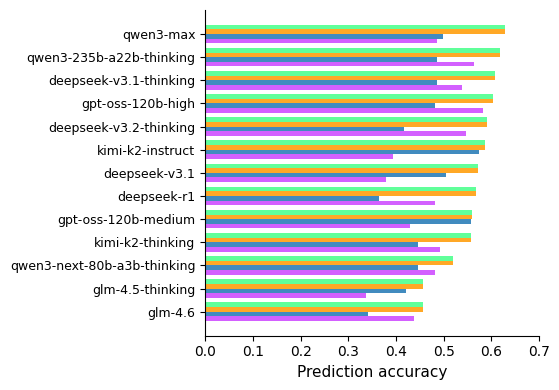

In [4]:
wide['accuracy_gamma'] = wide['accuracy_myopic']


models_sorted = wide.sort_values('accuracy_myopic', ascending=True).index.tolist()
n = len(models_sorted)
y = np.arange(n)

VAR_COLORS = [
    ('notree', '#cc44ff'),
    ('full',   '#1f77b4'),
    ('myopic', '#ff9900'),
    ('gamma',  '#44ff88'),
]
BAR_HEIGHT = 0.2

fig, ax = plt.subplots(figsize=(5.7, 4))

offsets = [-1.5, -0.5, 0.5, 1.5]
for (variant, color), offset in zip(VAR_COLORS, offsets):
    vals = [wide.loc[m, f'accuracy_{variant}'] for m in models_sorted]
    ax.barh(y + offset * BAR_HEIGHT, vals, BAR_HEIGHT,
            label=variant, color=color, alpha=0.85)

ax.set_yticks(y)
ax.set_yticklabels(models_sorted, fontsize=9)
ax.set_xlabel('Prediction accuracy', fontsize=11)
# ax.legend(loc='lower right')
ax.set_xlim(0, 0.7)
plt.tight_layout()
plt.savefig('figures/comparison_accuracy.pdf', bbox_inches='tight')
plt.show()


## 4. Bar chart: NLL per sample (lower = better)

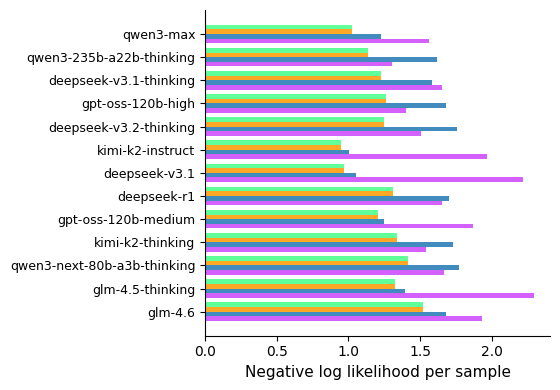

In [5]:

models_sorted_nll = wide.sort_values('accuracy_myopic', ascending=True).index.tolist()
n = len(models_sorted_nll)
y = np.arange(n)

fig, ax = plt.subplots(figsize=(5.7, 4))

offsets = [-1.5, -0.5, 0.5, 1.5]
for (variant, color), offset in zip(VAR_COLORS, offsets):
    vals = [wide.loc[m, f'nll_{variant}'] for m in models_sorted_nll]
    ax.barh(y + offset * BAR_HEIGHT, vals, BAR_HEIGHT,
            label=variant, color=color, alpha=0.85)

ax.set_yticks(y)
ax.set_yticklabels(models_sorted_nll, fontsize=9)
ax.set_xlabel('Negative log likelihood per sample', fontsize=11)
# ax.set_title('NLL per Sample: No-Tree vs Full vs Myopic vs Gamma (Open-Source)', fontsize=13)
# ax.legend(loc='lower right')

handles, labels = ax.get_legend_handles_labels()

mapping = {
    'notree': 'No-tree',
    'full': 'Full-tree',
    'myopic': 'Myopic',
    'gamma': 'Discount'
}

new_handles = []
new_labels = []

for h, l in zip(handles, labels):
    if l in mapping:   # filter + rename
        new_handles.append(h)
        new_labels.append(mapping[l])

# ax.legend(new_handles, new_labels, loc='center left', bbox_to_anchor=(1, 0.55), frameon=False, fontsize = 8)

plt.tight_layout()
plt.savefig('figures/comparison_nll.pdf', bbox_inches='tight')
plt.show()


## 5. Scatter: full vs myopic accuracy (per model)

Points **above** the diagonal → myopic fits better than full tree.

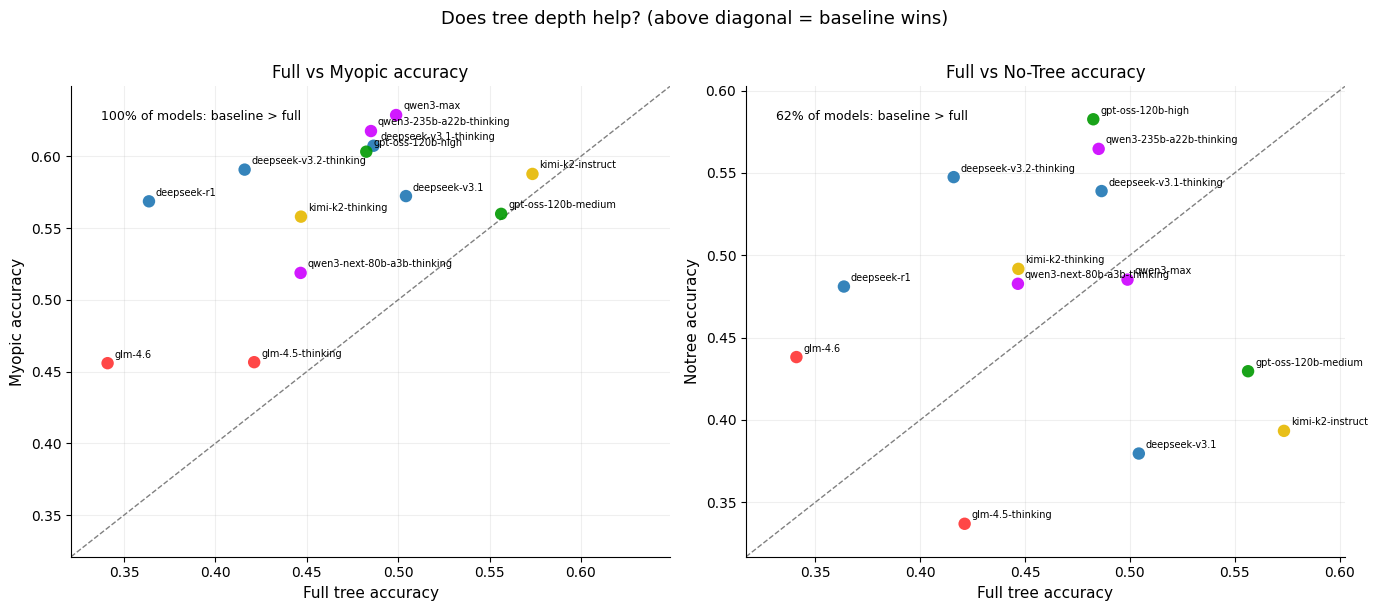

In [6]:
def model_color(name):
    n = name.lower()
    if 'oss'      in n:  return '#009900'
    if 'deepseek' in n:  return '#1f77b4'
    if 'qwen'     in n:  return '#cc00ff'
    if 'kimi'     in n:  return '#e6b800'
    if 'glm'      in n:  return '#ff3333'
    if 'llama'    in n:  return '#3A3939'
    return '#3A3939'

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, (xvar, yvar, title) in zip(axes, [
    ('accuracy_full', 'accuracy_myopic', 'Full vs Myopic accuracy'),
    ('accuracy_full', 'accuracy_notree', 'Full vs No-Tree accuracy'),
]):
    x = wide[xvar].values
    y_vals = wide[yvar].values
    cols = [model_color(m) for m in wide.index]

    lims = [min(x.min(), y_vals.min()) - 0.02,
            max(x.max(), y_vals.max()) + 0.02]
    ax.plot(lims, lims, '--', color='gray', lw=1, label='y = x')

    ax.scatter(x, y_vals, c=cols, s=80, alpha=0.9, edgecolors='none', zorder=3)
    for xi, yi, name in zip(x, y_vals, wide.index):
        ax.annotate(name, (xi, yi), xytext=(5, 4),
                    textcoords='offset points', fontsize=7)

    ax.set_xlabel('Full tree accuracy', fontsize=11)
    ax.set_ylabel(f'{yvar.split("_")[1].capitalize()} accuracy', fontsize=11)
    ax.set_title(title, fontsize=12)
    ax.grid(True, alpha=0.2)
    ax.set_xlim(lims); ax.set_ylim(lims)
    pct_above = 100 * (y_vals > x).mean()
    ax.text(0.05, 0.95, f'{pct_above:.0f}% of models: baseline > full',
            transform=ax.transAxes, fontsize=9, va='top')

plt.suptitle('Does tree depth help? (above diagonal = baseline wins)',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('figures/comparison_scatter_accuracy.pdf', facecolor='white')
plt.show()

## 6. Delta bar: accuracy gain of full over baselines

Positive = full tree is better; negative = baseline is better.

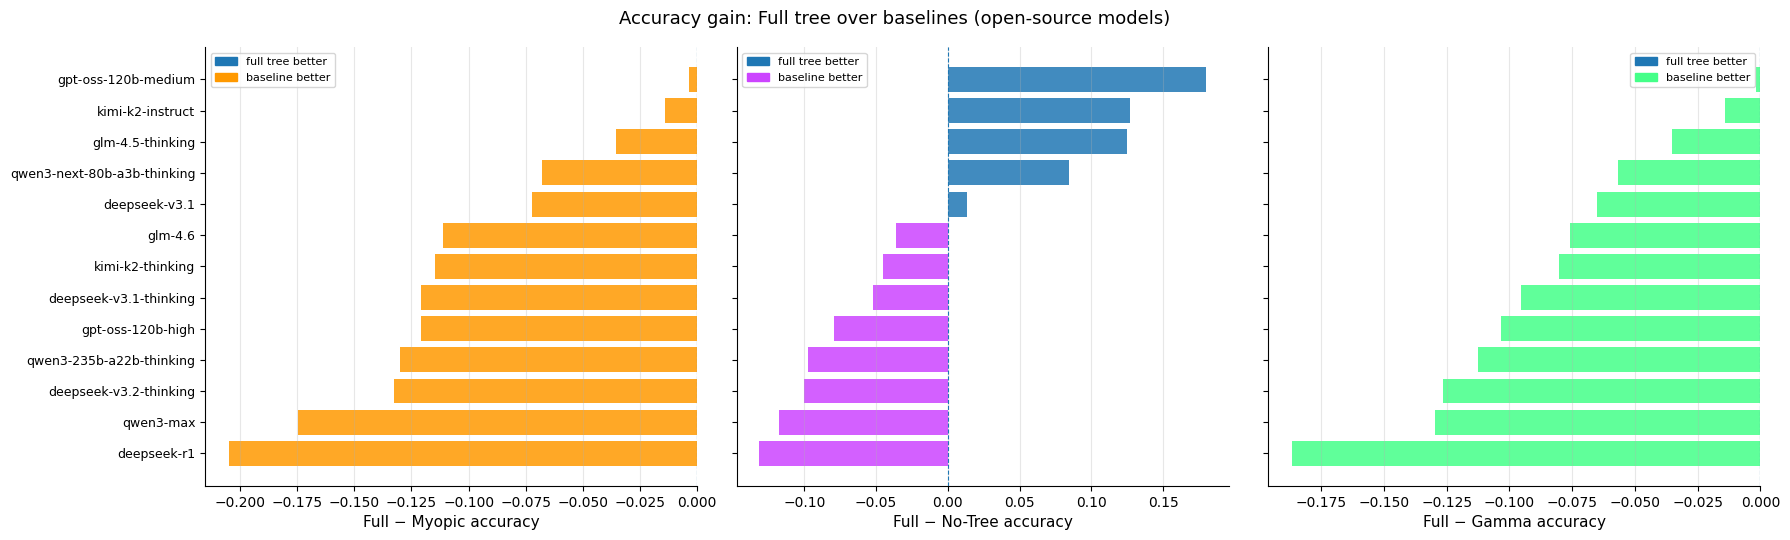

In [7]:

fig, axes = plt.subplots(1, 3, figsize=(18, max(5, n * 0.42)), sharey=True)

for ax, (col, label, color) in zip(axes, [
    ('delta_acc_full_vs_myopic', 'Full − Myopic accuracy',  '#ff9900'),
    ('delta_acc_full_vs_notree', 'Full − No-Tree accuracy', '#cc44ff'),
    ('delta_acc_full_vs_gamma',  'Full − Gamma accuracy',   '#44ff88'),
]):
    vals = wide.sort_values(col, ascending=True)
    bar_colors = ['#1f77b4' if v >= 0 else color for v in vals[col]]
    ax.barh(np.arange(len(vals)), vals[col], color=bar_colors, alpha=0.85)
    ax.axvline(0, lw=0.8, ls='--')
    ax.set_yticks(np.arange(len(vals)))
    ax.set_yticklabels(vals.index, fontsize=9)
    ax.set_xlabel(label, fontsize=11)
    ax.grid(True, alpha=0.3, axis='x')
    blue_patch  = mpatches.Patch(color='#1f77b4', label='full tree better')
    other_patch = mpatches.Patch(color=color,     label='baseline better')
    ax.legend(handles=[blue_patch, other_patch], fontsize=8)

plt.suptitle('Accuracy gain: Full tree over baselines (open-source models)', fontsize=13)
plt.tight_layout()
plt.show()


## 7. Statistical summary

Wilcoxon signed-rank test: is the full model systematically better than each baseline?

In [8]:

from scipy.stats import wilcoxon

for baseline in ['myopic', 'notree', 'gamma']:
    delta_acc = wide[f'delta_acc_full_vs_{baseline}'].dropna().values
    delta_nll = wide[f'delta_nll_full_vs_{baseline}'].dropna().values

    print(f'\n── Full vs {baseline.upper()} ──────────────────────')
    print(f'  Accuracy delta  mean={delta_acc.mean():+.4f}  '
          f'N full-better={(delta_acc > 0).sum()}/{len(delta_acc)}')
    print(f'  NLL delta       mean={delta_nll.mean():+.4f}  '
          f'N full-lower-NLL={(delta_nll > 0).sum()}/{len(delta_nll)}')

    if (delta_acc != 0).any():
        stat, p = wilcoxon(delta_acc)
        print(f'  Wilcoxon (accuracy):  W={stat:.1f}, p={p:.4f}')
    if (delta_nll != 0).any():
        stat, p = wilcoxon(delta_nll)
        print(f'  Wilcoxon (NLL):       W={stat:.1f}, p={p:.4f}')



── Full vs MYOPIC ──────────────────────
  Accuracy delta  mean=-0.1002  N full-better=0/13
  NLL delta       mean=-0.2707  N full-lower-NLL=0/13
  Wilcoxon (accuracy):  W=0.0, p=0.0002
  Wilcoxon (NLL):       W=0.0, p=0.0002

── Full vs NOTREE ──────────────────────
  Accuracy delta  mean=-0.0100  N full-better=5/13
  NLL delta       mean=+0.2401  N full-lower-NLL=7/13
  Wilcoxon (accuracy):  W=41.0, p=0.7869
  Wilcoxon (NLL):       W=29.0, p=0.2734

── Full vs GAMMA ──────────────────────
  Accuracy delta  mean=-0.0834  N full-better=0/13
  NLL delta       mean=-0.2707  N full-lower-NLL=0/13
  Wilcoxon (accuracy):  W=0.0, p=0.0002
  Wilcoxon (NLL):       W=0.0, p=0.0002


## 8. Does tree advantage correlate with model win-rate?

If the full tree advantage is larger for stronger models, tree search is a meaningful capability signal.

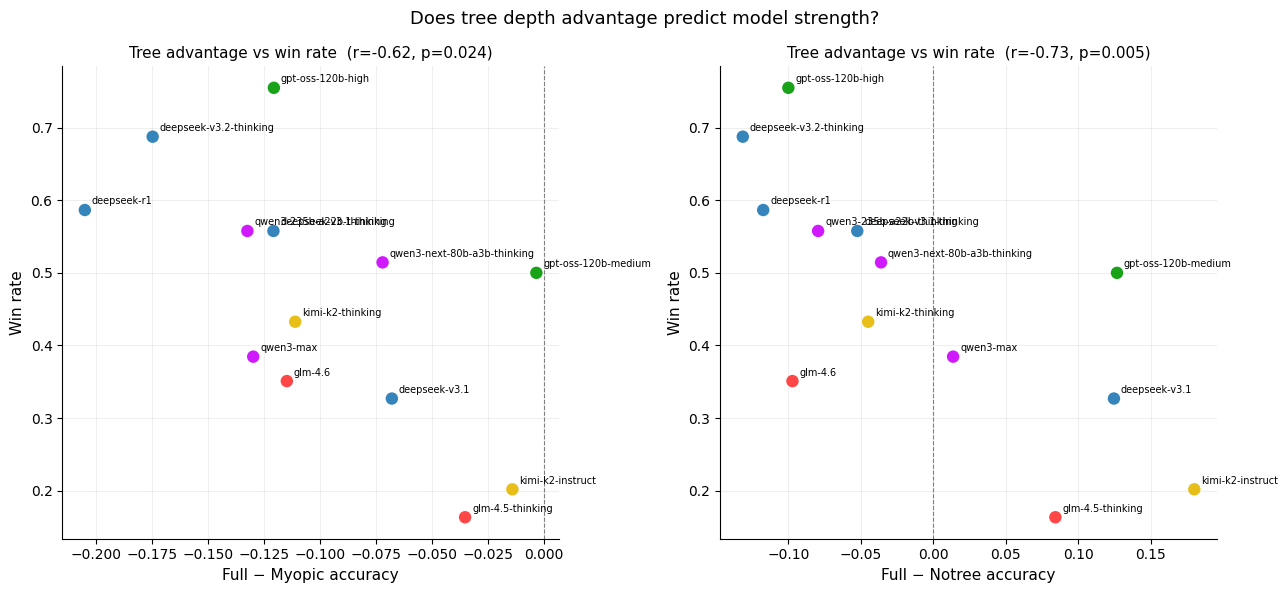

In [9]:

from scipy.stats import pearsonr

try:
    df_outcome = (
        pd.read_pickle('game_trees_df_annotated_preprocessed.pkl')
          .groupby(['game_path', 'model_names'])['outcome_perspective']
          .mean()
          .reset_index()
          .groupby('model_names')['outcome_perspective']
          .mean()
          .reset_index()
    )
    df_outcome['model'] = df_outcome['model_names'].map(
        lambda x: name_replacement.get(x, x)
    )
    win_rate = df_outcome.set_index('model')['outcome_perspective']
except Exception as e:
    print(f'Could not load win rates from pkl ({e}).')
    print('Skipping this cell — run in an environment with matching numpy version to enable.')
    win_rate = None

if win_rate is not None:
    fig, axes = plt.subplots(1, 2, figsize=(13, 6))

    for ax, baseline in zip(axes, ['myopic', 'notree']):
        models_shared = wide.index.intersection(win_rate.index)
        delta = wide.loc[models_shared, f'delta_acc_full_vs_{baseline}'].values
        wr    = win_rate.loc[models_shared].values
        cols  = [model_color(m) for m in models_shared]

        ax.scatter(delta, wr, c=cols, s=80, alpha=0.9, edgecolors='none', zorder=3)
        ax.axvline(0, color='gray', lw=0.8, ls='--')
        for d, w, name in zip(delta, wr, models_shared):
            ax.annotate(name, (d, w), xytext=(5, 4),
                        textcoords='offset points', fontsize=7)

        r, p = pearsonr(delta, wr)
        ax.set_xlabel(f'Full − {baseline.capitalize()} accuracy', fontsize=11)
        ax.set_ylabel('Win rate', fontsize=11)
        ax.set_title(f'Tree advantage vs win rate  (r={r:.2f}, p={p:.3f})', fontsize=11)
        ax.grid(True, alpha=0.2)

    plt.suptitle('Does tree depth advantage predict model strength?', fontsize=13)
    plt.tight_layout()
    plt.savefig('figures/comparison_delta_vs_winrate.pdf', facecolor='#444444')
    plt.show()


## 9. Heatmap: NLL across models × variants

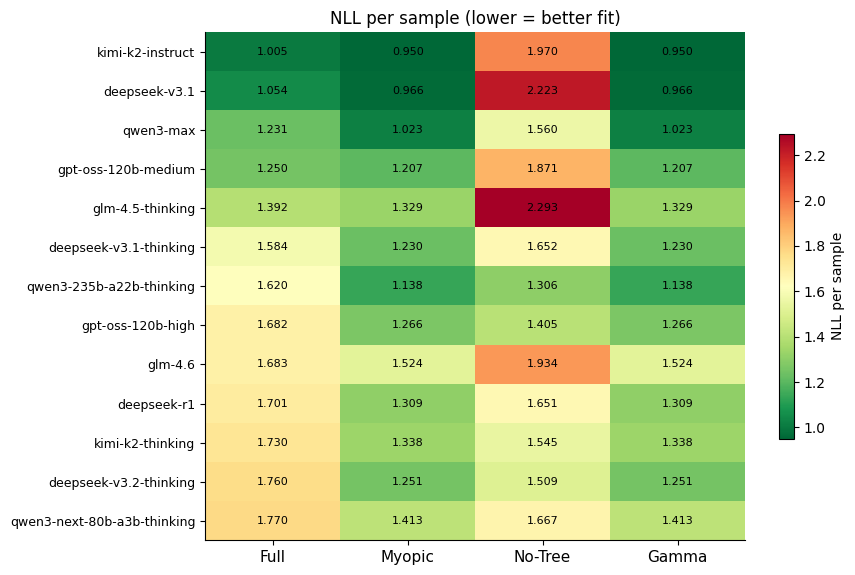

In [10]:

nll_mat = wide[['nll_full', 'nll_myopic', 'nll_notree', 'nll_gamma']].copy()
nll_mat.columns = ['Full', 'Myopic', 'No-Tree', 'Gamma']
nll_mat = nll_mat.sort_values('Full', ascending=True)

fig, ax = plt.subplots(figsize=(9, max(5, len(nll_mat) * 0.45)))
im = ax.imshow(nll_mat.values, aspect='auto', cmap='RdYlGn_r')

ax.set_xticks(range(4))
ax.set_xticklabels(nll_mat.columns, fontsize=11)
ax.set_yticks(range(len(nll_mat)))
ax.set_yticklabels(nll_mat.index, fontsize=9)

for i in range(len(nll_mat)):
    for j in range(4):
        val = nll_mat.values[i, j]
        ax.text(j, i, f'{val:.3f}', ha='center', va='center', fontsize=8, color='black')

plt.colorbar(im, ax=ax, label='NLL per sample', shrink=0.6)
ax.set_title('NLL per sample (lower = better fit)', fontsize=12)
plt.tight_layout()
plt.show()


## 10. Summary: proportion of models where full tree wins

In [11]:

print('=== Accuracy: fraction of models where full tree > baseline ===')
for baseline in ['myopic', 'notree', 'gamma']:
    col = f'delta_acc_full_vs_{baseline}'
    n_better = (wide[col] > 0).sum()
    n_total  = wide[col].notna().sum()
    mean_d   = wide[col].mean()
    print(f'  Full > {baseline:<8}: {n_better}/{n_total}  mean Δacc = {mean_d:+.4f}')

print()
print('=== NLL: fraction of models where full tree has lower NLL ===')
for baseline in ['myopic', 'notree', 'gamma']:
    col = f'delta_nll_full_vs_{baseline}'
    n_better = (wide[col] > 0).sum()
    n_total  = wide[col].notna().sum()
    mean_d   = wide[col].mean()
    print(f'  Full < {baseline:<8}: {n_better}/{n_total}  mean ΔNLL = {mean_d:+.4f}')


=== Accuracy: fraction of models where full tree > baseline ===
  Full > myopic  : 0/13  mean Δacc = -0.1002
  Full > notree  : 5/13  mean Δacc = -0.0100
  Full > gamma   : 0/13  mean Δacc = -0.0834

=== NLL: fraction of models where full tree has lower NLL ===
  Full < myopic  : 0/13  mean ΔNLL = -0.2707
  Full < notree  : 7/13  mean ΔNLL = +0.2401
  Full < gamma   : 0/13  mean ΔNLL = -0.2707


## 11. Fitted gamma values (continuation probability)\n\nγ = 0 → myopic (agent always stops and evaluates heuristically)  \nγ = 1 → full minimax (agent always continues to tree leaves)

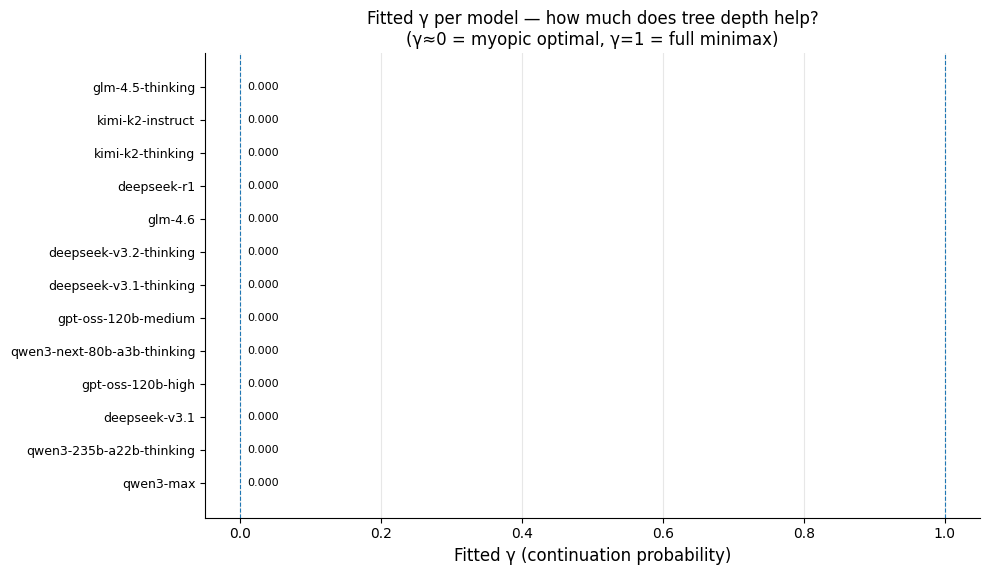


Median γ: 0.0000
Mean γ:   0.0000
Models with γ > 0.05: 0/13


In [12]:

# Extract fitted gamma values for open-source models from the gamma variant
df_gamma = df[df['variant'] == 'gamma'][['model', 'fitted_gamma']].copy()
df_gamma = df_gamma.sort_values('fitted_gamma', ascending=True).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(10, max(5, len(df_gamma) * 0.45)))

colors = ['#44ff88' if g > 0.05 else '#888888' for g in df_gamma['fitted_gamma']]
ax.barh(np.arange(len(df_gamma)), df_gamma['fitted_gamma'], color=colors, alpha=0.85)

ax.set_yticks(np.arange(len(df_gamma)))
ax.set_yticklabels(df_gamma['model'], fontsize=9)
ax.set_xlabel('Fitted γ (continuation probability)', fontsize=12)
ax.set_title('Fitted γ per model — how much does tree depth help?\n(γ≈0 = myopic optimal, γ=1 = full minimax)', fontsize=12)
ax.axvline(0, lw=0.8, ls='--')
ax.axvline(1, lw=0.8, ls='--')
ax.set_xlim(-0.05, 1.05)
ax.grid(True, alpha=0.3, axis='x')

# annotate values
for i, (_, row) in enumerate(df_gamma.iterrows()):
    ax.text(row['fitted_gamma'] + 0.01, i, f'{row["fitted_gamma"]:.3f}',
            va='center', fontsize=8)

plt.tight_layout()
plt.show()

print(f'\nMedian γ: {df_gamma["fitted_gamma"].median():.4f}')
print(f'Mean γ:   {df_gamma["fitted_gamma"].mean():.4f}')
print(f'Models with γ > 0.05: {(df_gamma["fitted_gamma"] > 0.05).sum()}/{len(df_gamma)}')


---\n## 12. What predicts which model fits better?\n\nTwo NLL differences of interest (both positive = myopic wins):\n- **Depth harm**: `nll_full − nll_myopic` — how much does tree depth hurt?\n- **Candidate gain**: `nll_notree − nll_myopic` — how much does the LLM's candidate selection help vs. all legal moves?\n\nWe correlate these with: win rate, search effort, tree depth, output tokens, and model type (thinking vs. non-thinking).

In [13]:

# ── Two key NLL deltas (positive = myopic wins) ────────────────────────────
analysis = wide[['nll_full', 'nll_myopic', 'nll_notree']].copy()
analysis['depth_harm']     = analysis['nll_full']   - analysis['nll_myopic']
analysis['candidate_gain'] = analysis['nll_notree'] - analysis['nll_myopic']

analysis['model_family'] = [
    'deepseek' if 'deepseek' in m.lower() else
    'qwen'     if 'qwen'     in m.lower() else
    'kimi'     if 'kimi'     in m.lower() else
    'glm'      if 'glm'      in m.lower() else
    'oss'      if 'oss'      in m.lower() else 'other'
    for m in analysis.index
]

# ── pkl uses its own display names — map them to match analysis.index ──────
pkl_name_map = {
    'qwen3-next-80b-a3b-thinking': 'qwen3-next-80b-a3b-thinking',
    'llama-v3.3-70b-instruct':     'llama-v3.3-70b',
}

# ── Win rate and search stats from preprocessed pkl (if loadable) ──────────
try:
    df_raw = pd.read_pickle('game_trees_df_annotated_preprocessed.pkl')

    win_rate = (
        df_raw.groupby(['game_path', 'model_names'])['outcome_perspective']
        .mean().reset_index()
        .groupby('model_names')['outcome_perspective'].mean()
    )
    win_rate.index = win_rate.index.map(lambda x: pkl_name_map.get(x, x))

    df_raw['log_tree_size'] = np.log(df_raw['total_nodes'] + 1)

    search_stats = df_raw.groupby('model_names').agg(
        mean_mean_ply      = ('mean_ply',        'mean'),
        mean_max_ply       = ('max_ply',         'mean'),
        mean_n_root        = ('n_root_moves',     'mean'),
        mean_log_tree_size = ('log_tree_size',    'mean'),
        mean_out_tokens    = ('output_tokens',    'mean'),
    )
    search_stats.index = search_stats.index.map(lambda x: pkl_name_map.get(x, x))

    analysis['win_rate']           = analysis.index.map(win_rate)
    analysis['mean_depth']         = analysis.index.map(search_stats['mean_mean_ply'])
    analysis['mean_max_ply']       = analysis.index.map(search_stats['mean_max_ply'])
    analysis['mean_n_root']        = analysis.index.map(search_stats['mean_n_root'])
    analysis['mean_log_tree_size'] = analysis.index.map(search_stats['mean_log_tree_size'])
    analysis['mean_out_tokens']    = analysis.index.map(search_stats['mean_out_tokens'])
    pkl_loaded = True

    missing = analysis[analysis['win_rate'].isna()].index.tolist()
    if missing:
        print(f'Models not found in pkl (excluded from scatter plots): {missing}')
    else:
        print(f'All {len(analysis)} models matched in pkl.')
except Exception as e:
    pkl_loaded = False
    print(f'Could not load pkl ({e}). Skipping win rate / search effort columns.')

analysis[['depth_harm', 'candidate_gain', 'win_rate', 'mean_depth', 'mean_max_ply', 'mean_log_tree_size', 'mean_out_tokens']]


All 13 models matched in pkl.


,depth_harm,candidate_gain,win_rate,mean_depth,mean_max_ply,mean_log_tree_size,mean_out_tokens
model,,,,,,,
kimi-k2-instruct,0.0543,1.0194,0.2019,1.0063,1.0217,0.9383,367.3137
gpt-oss-120b-medium,0.0434,0.6639,0.5000,1.0878,1.2735,1.6737,1991.3978
deepseek-v3.1,0.0886,1.2571,0.3269,1.0383,1.0768,1.1015,613.7873
qwen3-max,0.2076,0.5367,0.3846,1.1835,1.4112,1.5062,1096.9577
deepseek-v3.1-thinking,0.3534,0.4213,0.5577,1.3643,2.0077,2.1050,6758.1688
qwen3-235b-a22b-thinking,0.4823,0.1679,0.5577,1.2232,1.7365,2.0888,6706.8551
gpt-oss-120b-high,0.4156,0.1385,0.7548,1.5767,2.5273,2.4276,15233.5388
kimi-k2-thinking,0.3919,0.2070,0.4327,1.2258,1.6667,2.1130,4053.5106
qwen3-next-80b-a3b-thinking,0.3571,0.2540,0.5144,1.3553,2.0288,2.2854,8099.2746


### 12a. Scatter: win rate vs NLL deltas

Does model strength (win rate) predict how much tree depth hurts or how much candidate selection helps?

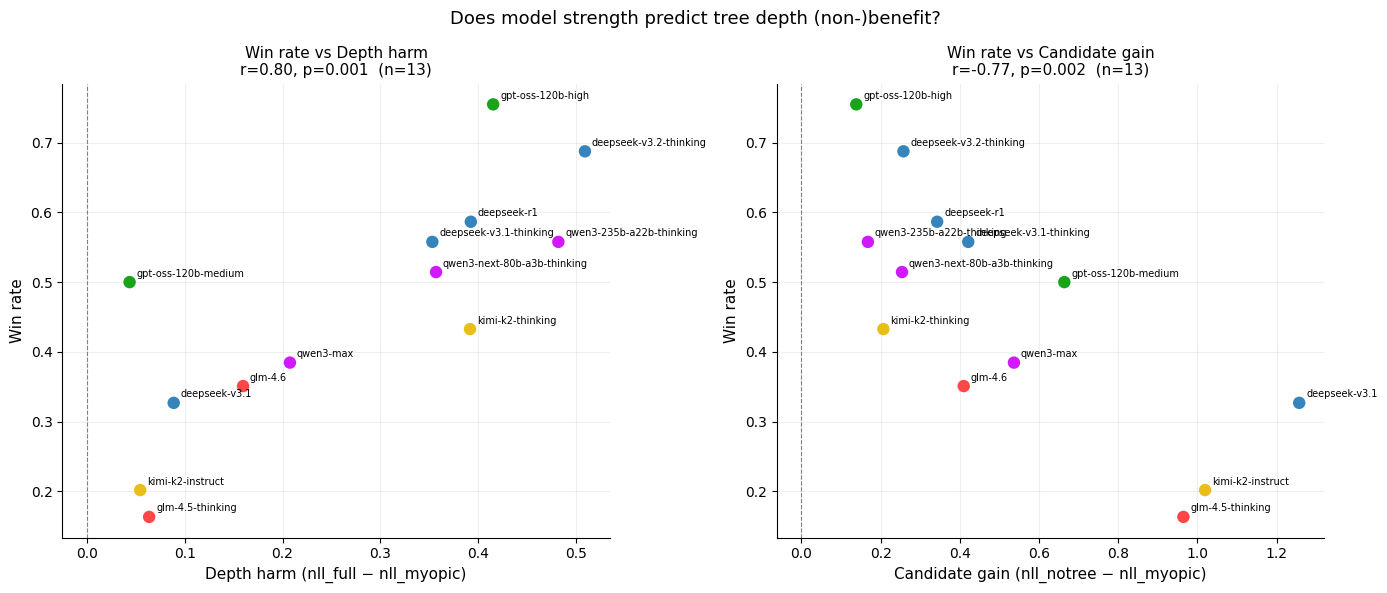

In [14]:

if not pkl_loaded:
    print('pkl not loaded — skipping win rate scatter plots.')
else:
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    for ax, (col, xlabel, title) in zip(axes, [
        ('depth_harm',     'Depth harm (nll_full − nll_myopic)',       'Win rate vs Depth harm'),
        ('candidate_gain', 'Candidate gain (nll_notree − nll_myopic)', 'Win rate vs Candidate gain'),
    ]):
        sub = analysis[['win_rate', col]].dropna()
        cols = [model_color(m) for m in sub.index]

        ax.scatter(sub[col], sub['win_rate'], c=cols, s=80, alpha=0.9, edgecolors='none', zorder=3)
        for xi, yi, name in zip(sub[col], sub['win_rate'], sub.index):
            ax.annotate(name, (xi, yi), xytext=(5, 4),
                        textcoords='offset points', fontsize=7)

        ax.axvline(0, color='gray', lw=0.8, ls='--')
        r, p = pearsonr(sub[col], sub['win_rate'])
        ax.set_xlabel(xlabel, fontsize=11)
        ax.set_ylabel('Win rate', fontsize=11)
        ax.set_title(f'{title}\nr={r:.2f}, p={p:.3f}  (n={len(sub)})', fontsize=11)
        ax.grid(True, alpha=0.2)

    plt.suptitle('Does model strength predict tree depth (non-)benefit?', fontsize=13)
    plt.tight_layout()
    plt.savefig('figures/corr_winrate_vs_deltas.pdf', facecolor='#444444')
    plt.show()


### 12b. Scatter: search behavior vs NLL deltas

Does a model that searches more benefit less from myopic fitting?

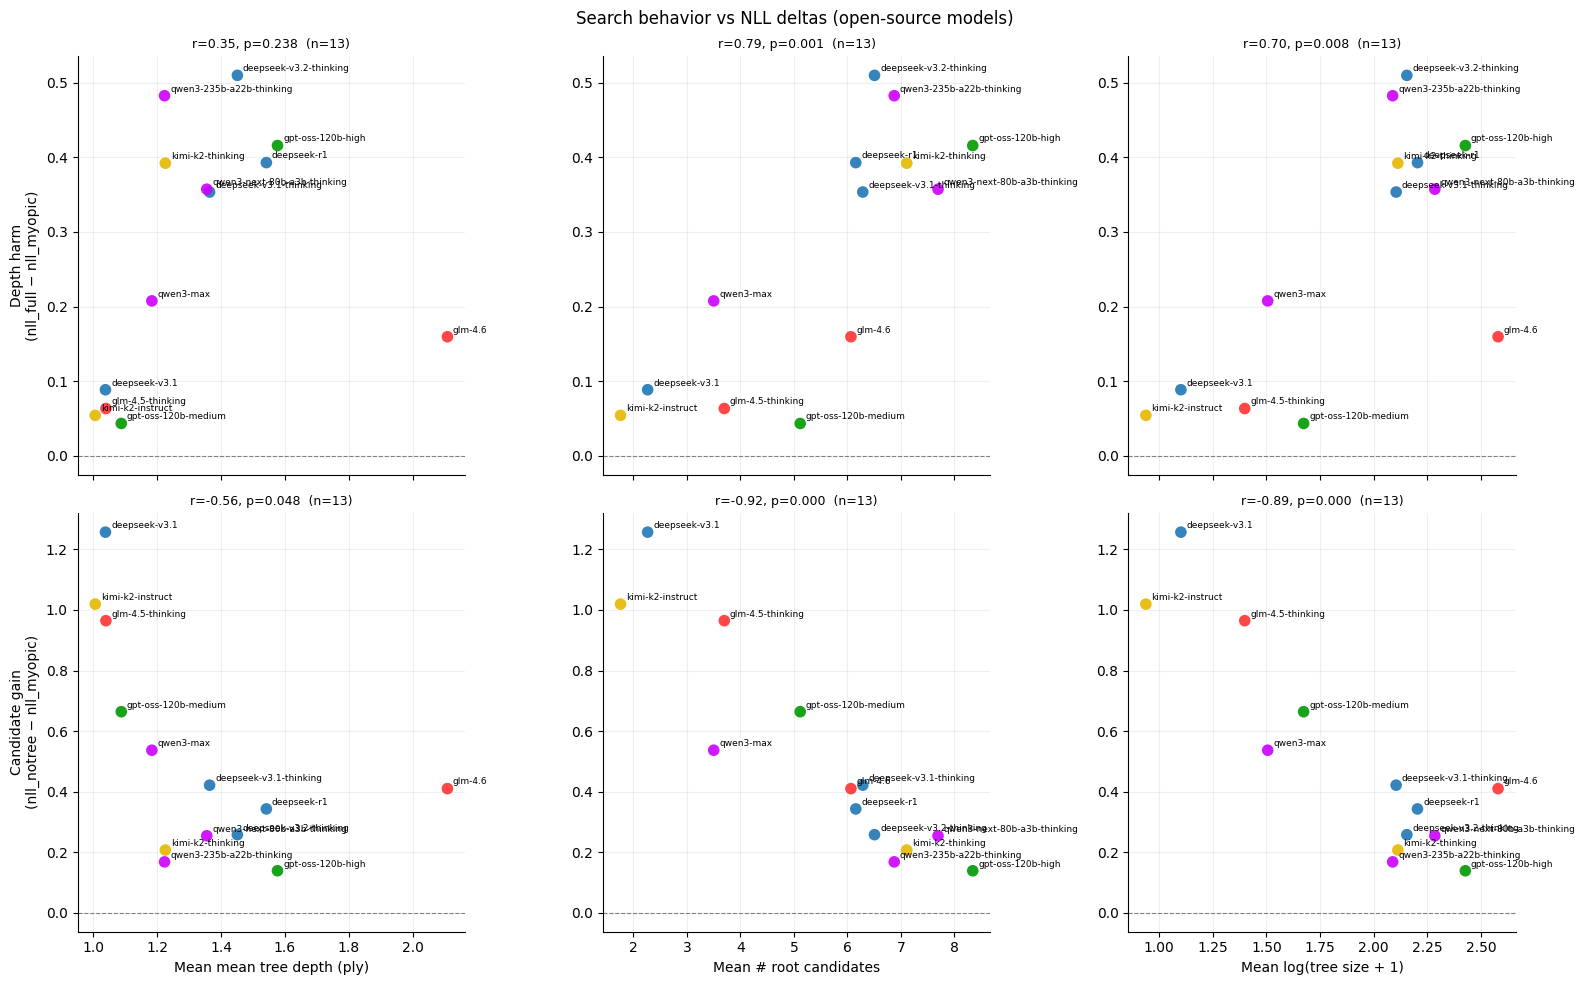

In [15]:

if not pkl_loaded:
    print('pkl not loaded — skipping search behavior scatter plots.')
else:
    effort_vars = [
        ('mean_depth',         'Mean mean tree depth (ply)'),
        ('mean_n_root',        'Mean # root candidates'),
        ('mean_log_tree_size', 'Mean log(tree size + 1)'),
    ]
    delta_vars = [
        ('depth_harm',     'Depth harm\n(nll_full − nll_myopic)'),
        ('candidate_gain', 'Candidate gain\n(nll_notree − nll_myopic)'),
    ]

    fig, axes = plt.subplots(len(delta_vars), len(effort_vars),
                             figsize=(16, 10), sharex='col')

    for col_i, (ev, ex_label) in enumerate(effort_vars):
        for row_i, (dv, dy_label) in enumerate(delta_vars):
            ax = axes[row_i, col_i]
            sub = analysis[[ev, dv]].dropna()
            cols = [model_color(m) for m in sub.index]

            ax.scatter(sub[ev], sub[dv], c=cols, s=70, alpha=0.9, edgecolors='none', zorder=3)
            for xi, yi, name in zip(sub[ev], sub[dv], sub.index):
                ax.annotate(name, (xi, yi), xytext=(4, 3),
                            textcoords='offset points', fontsize=6.5)

            ax.axhline(0, color='gray', lw=0.8, ls='--')
            r, p = pearsonr(sub[ev], sub[dv])
            ax.set_title(f'r={r:.2f}, p={p:.3f}  (n={len(sub)})', fontsize=9)
            if row_i == len(delta_vars) - 1:
                ax.set_xlabel(ex_label, fontsize=10)
            if col_i == 0:
                ax.set_ylabel(dy_label, fontsize=10)
            ax.grid(True, alpha=0.2)

    plt.suptitle('Search behavior vs NLL deltas (open-source models)', fontsize=12)
    plt.tight_layout()
    plt.savefig('figures/corr_effort_vs_deltas.pdf', facecolor='#444444')
    plt.show()


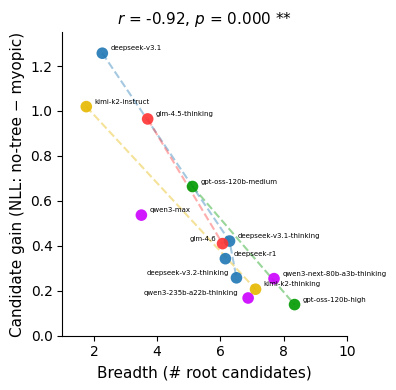

Saved: figures/corr_candidate_gain_vs_n_root.pdf


In [16]:


from scipy.stats import pearsonr
sub = analysis[['mean_n_root', 'candidate_gain']].dropna()
cols = [model_color(m) for m in sub.index]

fig, ax = plt.subplots(figsize=(4, 4))
ax.scatter(sub['mean_n_root'], sub['candidate_gain'], c=cols, s=70, alpha=0.9, edgecolors='none', zorder=3)

manual_offsets = {
    'qwen3-235b-a22b-thinking': (-75, 2),
    # 'qwen3-next-80b-a3b-thinking': (6, -6),
    'deepseek-v3.2-thinking': (-65, 2),
    'glm-4.6': (-24, 2),
}

for xi, yi, name in zip(sub['mean_n_root'], sub['candidate_gain'], sub.index):
    offset = manual_offsets.get(name, (6, 2))
    ax.annotate(name, (xi, yi), xytext=offset, textcoords='offset points', fontsize=5)




line_groups = [
    ('#009900', ['gpt-oss-120b-medium', 'gpt-oss-120b-high']),
    ('#1f77b4', ['deepseek-v3.1', 'deepseek-v3.1-thinking', 'deepseek-v3.2-thinking']),
    ('#e6b800', ['kimi-k2-instruct', 'kimi-k2-thinking']),
    ('#ff3333', ['glm-4.5-thinking', 'glm-4.6']),
]

# Use the same coordinates as the scatter plot
model_coords = {
    m: (row['mean_n_root'], row['candidate_gain'])
    for m, row in sub.iterrows()
}

for color, group in line_groups:
    group_present = [m for m in group if m in model_coords]
    if len(group_present) >= 2:
        xs = [model_coords[m][0] for m in group_present]
        ys = [model_coords[m][1] for m in group_present]
        ax.plot(
            xs, ys,
            color=color,
            linestyle='--',
            linewidth=1.5,
            alpha=0.4,
            zorder=0
        )



ax.set_xlim(1, 10)
ax.set_ylim(0, 1.35)

r, p = pearsonr(sub['mean_n_root'], sub['candidate_gain'])
sig = '**' if p < 0.01 else ('*' if p < 0.05 else ('.' if p < 0.1 else ''))
ax.set_title(rf'$r$ = {r:+.2f}, $p$ = {p:.3f} {sig}', fontsize=11)
ax.set_xlabel('Breadth (# root candidates)', fontsize=11)
ax.set_ylabel('Candidate gain (NLL: no-tree − myopic)', fontsize=11)
plt.tight_layout()
plt.savefig('figures/corr_candidate_gain_vs_n_root.pdf', facecolor='white')
plt.show()
print('Saved: figures/corr_candidate_gain_vs_n_root.pdf')


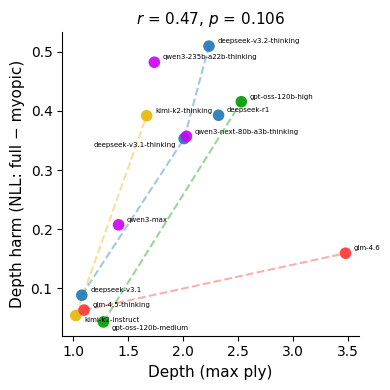

Saved: figures/corr_depth_harm_vs_max_ply.pdf


In [17]:

sub = analysis[['mean_max_ply', 'depth_harm']].dropna()
cols = [model_color(m) for m in sub.index]

fig, ax = plt.subplots(figsize=(4, 4))

ax.scatter(sub['mean_max_ply'], sub['depth_harm'], c=cols, s=70, alpha=0.9, edgecolors='none', zorder=3)

manual_offsets = {
    'kimi-k2-instruct': (6, -5),
    'gpt-oss-120b-medium': (6, -6),
    'deepseek-v3.1-thinking': (-65, -6),
    # 'glm-4.6': (-24, 2),
}

for xi, yi, name in zip(sub['mean_max_ply'], sub['depth_harm'], sub.index):
    offset = manual_offsets.get(name, (6, 2))
    ax.annotate(name, (xi, yi), xytext=offset, textcoords='offset points', fontsize=5)


line_groups = [
    ('#009900', ['gpt-oss-120b-medium', 'gpt-oss-120b-high']),
    ('#1f77b4', ['deepseek-v3.1', 'deepseek-v3.1-thinking', 'deepseek-v3.2-thinking']),
    ('#e6b800', ['kimi-k2-instruct', 'kimi-k2-thinking']),
    ('#ff3333', ['glm-4.5-thinking', 'glm-4.6']),
]

# Use the same coordinates as the scatter plot
model_coords = {
    m: (row['mean_max_ply'], row['depth_harm'])
    for m, row in sub.iterrows()
}

for color, group in line_groups:
    group_present = [m for m in group if m in model_coords]
    if len(group_present) >= 2:
        xs = [model_coords[m][0] for m in group_present]
        ys = [model_coords[m][1] for m in group_present]
        ax.plot(
            xs, ys,
            color=color,
            linestyle='--',
            linewidth=1.5,
            alpha=0.4,
            zorder=0
        )


r, p = pearsonr(sub['mean_max_ply'], sub['depth_harm'])
sig = '**' if p < 0.01 else ('*' if p < 0.05 else ('.' if p < 0.1 else ''))
ax.set_title(rf'$r$ = {r:.2f}, $p$ = {p:.3f} {sig}', fontsize=11)
ax.set_xlabel('Depth (max ply)', fontsize=11)
ax.set_ylabel('Depth harm (NLL: full − myopic)', fontsize=11)
plt.tight_layout()
plt.savefig('figures/corr_depth_harm_vs_max_ply.pdf', facecolor='white')
plt.show()
print('Saved: figures/corr_depth_harm_vs_max_ply.pdf')


### 12c. Scatter: output tokens vs NLL deltas

More verbose CoT → more tree nodes → does this predict deeper depth harm?

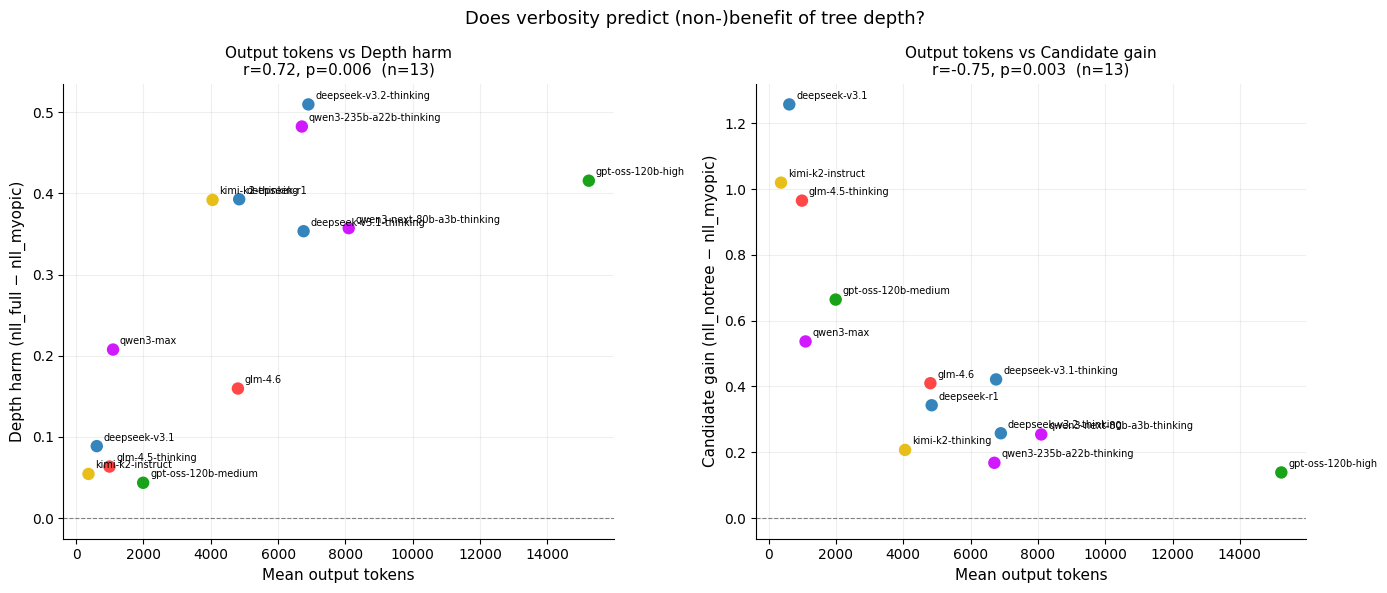

In [18]:

if not pkl_loaded:
    print('pkl not loaded — skipping output token scatter plots.')
else:
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    for ax, (col, ylabel, title) in zip(axes, [
        ('depth_harm',     'Depth harm (nll_full − nll_myopic)',       'Output tokens vs Depth harm'),
        ('candidate_gain', 'Candidate gain (nll_notree − nll_myopic)', 'Output tokens vs Candidate gain'),
    ]):
        sub = analysis[['mean_out_tokens', col]].dropna()
        cols = [model_color(m) for m in sub.index]

        ax.scatter(sub['mean_out_tokens'], sub[col], c=cols, s=80, alpha=0.9, edgecolors='none', zorder=3)
        for xi, yi, name in zip(sub['mean_out_tokens'], sub[col], sub.index):
            ax.annotate(name, (xi, yi), xytext=(5, 4),
                        textcoords='offset points', fontsize=7)

        ax.axhline(0, color='gray', lw=0.8, ls='--')
        r, p = pearsonr(sub['mean_out_tokens'], sub[col])
        ax.set_xlabel('Mean output tokens', fontsize=11)
        ax.set_ylabel(ylabel, fontsize=11)
        ax.set_title(f'{title}\nr={r:.2f}, p={p:.3f}  (n={len(sub)})', fontsize=11)
        ax.grid(True, alpha=0.2)

    plt.suptitle('Does verbosity predict (non-)benefit of tree depth?', fontsize=13)
    plt.tight_layout()
    plt.savefig('figures/corr_tokens_vs_deltas.pdf', facecolor='#444444')
    plt.show()


### 12d. Correlation matrix summary

Pearson r between all predictors and the two NLL deltas.

=== Pearson r (and significance: * p<.05, . p<.10) ===

  win_rate                   → depth_harm        : r=+0.804  p=0.001 *
  win_rate                   → candidate_gain    : r=-0.771  p=0.002 *

  mean_depth                 → depth_harm        : r=+0.352  p=0.238 
  mean_depth                 → candidate_gain    : r=-0.557  p=0.048 *

  mean_n_root                → depth_harm        : r=+0.790  p=0.001 *
  mean_n_root                → candidate_gain    : r=-0.924  p=0.000 *

  mean_log_tree_size         → depth_harm        : r=+0.701  p=0.008 *
  mean_log_tree_size         → candidate_gain    : r=-0.887  p=0.000 *

  mean_out_tokens            → depth_harm        : r=+0.719  p=0.006 *
  mean_out_tokens            → candidate_gain    : r=-0.752  p=0.003 *



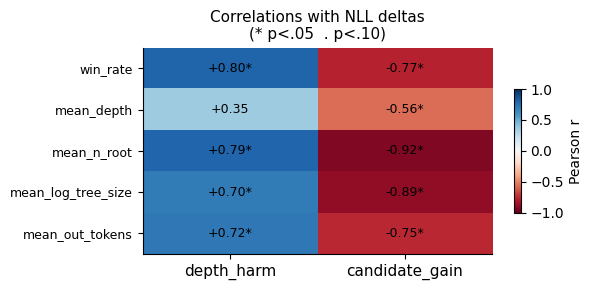

In [19]:

predictors_pkl = ['win_rate', 'mean_depth', 'mean_n_root', 'mean_log_tree_size', 'mean_out_tokens']
targets        = ['depth_harm', 'candidate_gain']

avail = [c for c in (predictors_pkl if pkl_loaded else []) if c in analysis.columns]

rows = []
for pred in avail:
    row = {'predictor': pred}
    for tgt in targets:
        sub = analysis[[pred, tgt]].dropna()
        if len(sub) >= 3:
            r, p = pearsonr(sub[pred].astype(float), sub[tgt].astype(float))
            row[f'r_{tgt}']   = r
            row[f'p_{tgt}']   = p
            row[f'sig_{tgt}'] = '*' if p < 0.05 else ('.' if p < 0.1 else '')
        else:
            row[f'r_{tgt}'] = float('nan')
            row[f'p_{tgt}'] = float('nan')
            row[f'sig_{tgt}'] = ''
    rows.append(row)

corr_df = pd.DataFrame(rows).set_index('predictor')

print('=== Pearson r (and significance: * p<.05, . p<.10) ===\n')
for pred in corr_df.index:
    for tgt in targets:
        r   = corr_df.loc[pred, f'r_{tgt}']
        p   = corr_df.loc[pred, f'p_{tgt}']
        sig = corr_df.loc[pred, f'sig_{tgt}']
        print(f'  {pred:<26} → {tgt:<18}: r={r:+.3f}  p={p:.3f} {sig}')
    print()

# ── heatmap of r values ───────────────────────────────────────────────────
r_mat = corr_df[[f'r_{t}' for t in targets]].rename(
    columns={f'r_{t}': t for t in targets}
).astype(float)

fig, ax = plt.subplots(figsize=(6, max(3, len(r_mat) * 0.5)))
im = ax.imshow(r_mat.values, aspect='auto', cmap='RdBu', vmin=-1, vmax=1)

ax.set_xticks(range(len(targets)))
ax.set_xticklabels(targets, fontsize=11)
ax.set_yticks(range(len(r_mat)))
ax.set_yticklabels(r_mat.index, fontsize=9)

for i in range(len(r_mat)):
    for j in range(len(targets)):
        val = r_mat.values[i, j]
        sig = corr_df.iloc[i][f'sig_{targets[j]}']
        ax.text(j, i, f'{val:+.2f}{sig}', ha='center', va='center', fontsize=9, color='black')

plt.colorbar(im, ax=ax, label='Pearson r', shrink=0.6)
ax.set_title('Correlations with NLL deltas\n(* p<.05  . p<.10)', fontsize=11)
plt.tight_layout()
plt.savefig('figures/corr_matrix.pdf', facecolor='#444444')
plt.show()


## 13. Win rate as a function of prediction accuracy

Does a model whose moves are better predicted by the myopic heuristic model
also play better (higher win rate)?
Higher accuracy means the cognitive model explains the model's choices well;
if well-explained models also win more, it implies the heuristic captures
the computationally useful aspects of the model's strategy.

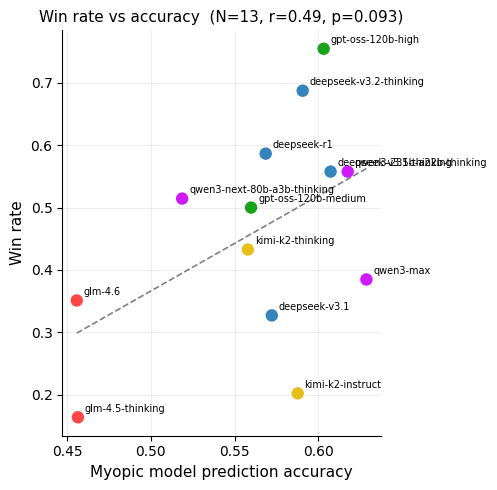

N=13, r=0.485, p=0.093


In [20]:

if win_rate is not None:
    models_shared = wide.index.intersection(win_rate.index)
    acc  = wide.loc[models_shared, 'accuracy_myopic'].values
    wr   = win_rate.loc[models_shared].values
    cols = [model_color(m) for m in models_shared]

    fig, ax = plt.subplots(figsize=(5, 5))
    ax.scatter(acc, wr, c=cols, s=80, alpha=0.9, edgecolors='none', zorder=3)
    for x, y, name in zip(acc, wr, models_shared):
        ax.annotate(name, (x, y), xytext=(5, 4),
                    textcoords='offset points', fontsize=7)

    m_fit, b_fit = np.polyfit(acc, wr, 1)
    x_line = np.linspace(acc.min(), acc.max(), 100)
    ax.plot(x_line, m_fit * x_line + b_fit, color='gray', lw=1.2, ls='--', zorder=2)

    r, p = pearsonr(acc, wr)
    ax.set_xlabel('Myopic model prediction accuracy', fontsize=11)
    ax.set_ylabel('Win rate', fontsize=11)
    ax.set_title(f'Win rate vs accuracy  (N={len(acc)}, r={r:.2f}, p={p:.3f})', fontsize=11)
    ax.grid(True, alpha=0.2)

    plt.tight_layout()
    plt.savefig('figures/accuracy_vs_winrate_open_source.pdf',
                bbox_inches='tight', facecolor='#444444')
    plt.show()
    print(f'N={len(acc)}, r={r:.3f}, p={p:.3f}')
else:
    print('win_rate not available — run cell 17 first.')
